# PCA (Principal Component Analysis)

PCA stands for **Principal Component Analysis**.

It is a **Dimensionality Reduction** technique.

PCA takes many features and transforms them into a smaller number of new features called **Principal Components**, while trying to preserve as much information (variance) as possible.

---

# Why Do We Need PCA?

Suppose our dataset has:

```text
100 Features
```

Some features may contain similar information.

For example:

```text
Height
Weight
BMI
Body Size
```

These features may be correlated.

Instead of using all 100 features, PCA may transform them into:

```text
100 Features
      ↓
      PCA
      ↓
20 Principal Components
```

We reduced the number of features while keeping most of the important information.

---

# Main Idea

PCA looks for directions in the data where the data varies the most.

Think of a dataset like this:

```text
        •
      •
    •
  •
 •
```

The data has a strong direction:

```text
        ↗
      ↗
    ↗
  ↗
↗
```

PCA finds this direction and calls it:

```text
PC1
```

The second most important direction becomes:

```text
PC2
```

---

# What is a Principal Component?

A Principal Component is a **new feature created by combining the original features**.

For example:

```text
Original Features

X1 = Age
X2 = Income
X3 = Experience
```

PCA may create:

```text
PC1 = 0.5X1 + 0.7X2 + 0.4X3
```

and

```text
PC2 = -0.3X1 + 0.2X2 + 0.8X3
```

So PCA does **not simply delete columns**.

It creates **new transformed features**.

---

# Important Concept: Variance

PCA tries to preserve **maximum variance**.

Variance tells us how spread out the data is.

```text
Low Variance

• • • •
```

There isn't much information in the spread.

While:

```text
High Variance

•             •

      •

  •

              •
```

There is much more variation.

PCA prefers directions with **high variance**.

---

# PC1 — First Principal Component

PC1 is the direction that captures the **maximum possible variance**.

```text
Original Data

       •
     •
   •
 •
•

       ↗
     ↗
   ↗
 ↗
↗

       PC1
```

PC1 contains the most information.

---

# PC2 — Second Principal Component

PC2 captures the maximum remaining variance while being **orthogonal (perpendicular)** to PC1.

```text
             PC2
              ↑
              │
              │
              │
──────────────┼──────────────→ PC1
```

So:

```text
PC1 → Maximum Variance

PC2 → Next Maximum Variance
```

And:

```text
PC1 ⟂ PC2
```

---

# Principal Components Order

PCA creates:

```text
PC1
 ↓
Most Variance

PC2
 ↓
Second Most Variance

PC3
 ↓
Third Most Variance

PC4
 ↓
Fourth Most Variance
```

Therefore:

```text
Variance(PC1)
>
Variance(PC2)
>
Variance(PC3)
>
Variance(PC4)
```

---

# PCA Workflow

```text
Original Dataset
       ↓
Standardization
       ↓
Covariance Matrix
       ↓
Eigenvalues & Eigenvectors
       ↓
Sort by Eigenvalues
       ↓
Select Principal Components
       ↓
Transform Dataset
       ↓
Reduced Dataset
```

---

# Step 1 — Standardize Data

PCA is affected by feature scale.

Suppose:

```text
Age       → 20–80

Income    → 20,000–500,000
```

Income has much larger numerical values.

Without scaling, it can dominate the PCA.

So we usually standardize first:

$$
z = \frac{x-\mu}{\sigma}
$$

Using:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

---

# Step 2 — Covariance Matrix

PCA looks at relationships between features using the **Covariance Matrix**.

For example:

```text
        Age   Income   Experience

Age       ✓      ↕          ↕

Income    ↕      ✓          ↕

Experience↕      ↕          ✓
```

It tells PCA how features vary together.

---

# Step 3 — Eigenvalues

Eigenvalues tell us how much variance each Principal Component captures.

Example:

```text
PC1 → 55%

PC2 → 25%

PC3 → 12%

PC4 → 8%
```

Total:

```text
55 + 25 + 12 + 8 = 100%
```

---

# Step 4 — Eigenvectors

Eigenvectors tell us the **direction/orientation** of each Principal Component.

Think:

```text
Eigenvalue
    ↓
How much information?

Eigenvector
    ↓
Which direction?
```

---

# Step 5 — Select Components

Suppose:

```text
PC1 → 60%
PC2 → 25%
PC3 → 10%
PC4 → 5%
```

If we choose:

```text
PC1 + PC2
```

we preserve:

```text
60 + 25 = 85%
```

of the original variance.

So:

```text
4 Features
    ↓
PCA
    ↓
2 Components
    ↓
85% Variance Retained
```

---

# Explained Variance Ratio

`explained_variance_ratio_` tells us the percentage of total variance captured by each component.

```python
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
```

Example:

```text
[0.60, 0.25, 0.10, 0.05]
```

Meaning:

```text
PC1 → 60%
PC2 → 25%
PC3 → 10%
PC4 → 5%
```

---

# Cumulative Explained Variance

We can calculate cumulative variance:

```python
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)
```

Example:

```text
PC1 → 60%

PC1 + PC2 → 85%

PC1 + PC2 + PC3 → 95%

PC1 + PC2 + PC3 + PC4 → 100%
```

---

# Choosing Number of Components

Instead of guessing:

```python
PCA(n_components=2)
```

we can tell PCA to retain a percentage of variance.

For example:

```python
pca = PCA(n_components=0.95)
```

This means:

> Keep enough Principal Components to preserve **95% of the variance**.

Example:

```text
100 Features
      ↓
PCA(0.95)
      ↓
18 Components
```

The exact number depends on the dataset.

---

# PCA Syntax

### Fixed Number of Components

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
```

---

### Preserve 95% Variance

```python
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)
```

---

# PCA with Train/Test Data

⚠️ **Important: Avoid Data Leakage.**

Do NOT do:

```python
X_scaled = scaler.fit_transform(X)

X_train, X_test = train_test_split(X_scaled)
```

Instead:

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Then:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
```

Then PCA:

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)
```

### Remember

```text
TRAIN

fit_transform()
     ↓
Scaler
     ↓
PCA


TEST

transform()
     ↓
Scaler
     ↓
PCA
```

Never `fit()` PCA on the test data.

---

# PCA Visualization

If we reduce the dataset to 2 components:

```python
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
```

We can plot:

```python
import matplotlib.pyplot as plt

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA")
plt.show()
```

Now:

```text
        PC2
         ↑
         │     ● ●
         │   ● ●
         │
         │
         │             ▲ ▲
         │           ▲ ▲
         └──────────────────→ PC1
```

We can visualize high-dimensional data in **2D**.

---

# PCA and Machine Learning

PCA can be placed before a model:

```text
Raw Features
      ↓
StandardScaler
      ↓
PCA
      ↓
Machine Learning Model
      ↓
Prediction
```

Example:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("classifier", LogisticRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# Advantages

✅ Reduces dimensionality

✅ Removes some redundant information

✅ Can reduce training time

✅ Can help with high-dimensional datasets

✅ Useful for visualization

✅ Can reduce noise

---

# Disadvantages

❌ New features become harder to interpret

❌ Information can be lost

❌ Must usually scale features first

❌ Not always useful for every dataset

❌ Principal Components are combinations of original features

---

# PCA Does NOT Mean Feature Selection

This is very important.

### Feature Selection

Keeps original features:

```text
Age
Income
Height
Weight

        ↓

Age
Income
```

The original meaning remains.

---

### PCA

Creates new features:

```text
Age
Income
Height
Weight

        ↓ PCA

PC1
PC2
```

PC1 might contain some combination of:

```text
Age + Income + Height + Weight
```

So you lose direct interpretability.

---

# PCA vs Feature Selection

| Feature Selection | PCA |
|---|---|
| Selects original features | Creates new features |
| Easy to interpret | Harder to interpret |
| No transformation | Transformation |
| Keeps original meaning | Loses original feature meaning |
| Example: SelectKBest | Example: PCA |

---

# When Should You Use PCA?

PCA is especially useful when:

```text
Many Features
      +
Highly Correlated Features
      +
Need Dimensionality Reduction
```

Example:

```text
500 Features
      ↓
PCA
      ↓
50 Components
```

---

# When Should You NOT Use PCA?

Avoid PCA when:

### 1. Interpretability is extremely important

If you need to explain:

```text
"Income caused this prediction."
```

PCA makes this difficult because the model sees:

```text
PC1
PC2
PC3
```

instead of the original features.

---

### 2. You only have a few features

If you have:

```text
5 Features
```

PCA may not provide much benefit.

---

### 3. Your model already handles high-dimensional data well

Tree-based models such as:

```text
Decision Tree
Random Forest
XGBoost
LightGBM
```

often don't need PCA.

---

# PCA and Random Forest / XGBoost

Usually:

```text
Random Forest
XGBoost
LightGBM
CatBoost
```

do **not** require PCA.

For these models, keeping the original features is often preferable because tree-based models can naturally select useful features through their splits.

PCA is much more commonly useful with models such as:

```text
Logistic Regression
SVM
KNN
Neural Networks
```

especially when there are many correlated features.

---

# The Most Important PCA Concepts

Remember these:

```text
PCA
│
├── Dimensionality Reduction
│
├── Principal Components
│
├── Variance
│
├── Covariance Matrix
│
├── Eigenvectors
│
├── Eigenvalues
│
├── Explained Variance
│
└── Standardization
```

---

# Simple Example

Suppose:

```text
X1 = Height
X2 = Weight
X3 = BMI
```

These features are highly correlated.

```text
Height ─────┐
Weight ─────┼──→ Similar Information
BMI ────────┘
```

PCA can transform them:

```text
Height
Weight       ───→ PCA ───→ PC1
BMI                    └──→ PC2
```

Maybe:

```text
PC1 = 90% Variance

PC2 = 8% Variance

PC3 = 2% Variance
```

We can keep:

```text
PC1 + PC2

= 98% Variance
```

and reduce:

```text
3 Features
    ↓
2 Components
```

---

# One-Line Definition

> **PCA is a dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated Principal Components while preserving as much variance (information) as possible.**

---

# ⭐ Remember This

```text
Standardize
     ↓
Find Directions of Maximum Variance
     ↓
PC1 = Maximum Variance
     ↓
PC2 = Next Maximum Variance
     ↓
PC3 = Next Maximum Variance
     ↓
Choose Components
     ↓
Transform Data
```

### The core idea:

> **PCA does not simply remove columns. It creates new axes (Principal Components) that capture the most important variation in the data.**

In [1]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd 
%matplotlib inline

In [2]:
## Load Data set 
from sklearn.datasets import load_breast_cancer

In [3]:
dataset = load_breast_cancer()

In [4]:
dataset["DESCR"]

'.. _breast_cancer_dataset:\n\nBreast cancer Wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [6]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
dataset.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [9]:
dataset.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [10]:
df = pd.DataFrame(dataset["data"], columns=dataset["feature_names"])

In [11]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


___
# Standardize Features

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

scaler.fit(df)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
scaled_data = scaler.transform(df)

In [15]:
scaled_data 

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

___
# applying The PCA Algo 

In [16]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components= 2)  # I want to convet the Entire data into 2 Component
# extract 2 cols from enitre Data 

In [21]:
data_pca = pca.fit_transform(scaled_data)

In [ ]:
data_pca  # see now data has only 2 cols 
           

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

In [23]:
pca.explained_variance_

array([13.30499079,  5.7013746 ])

Text(0, 0.5, 'PCA2')

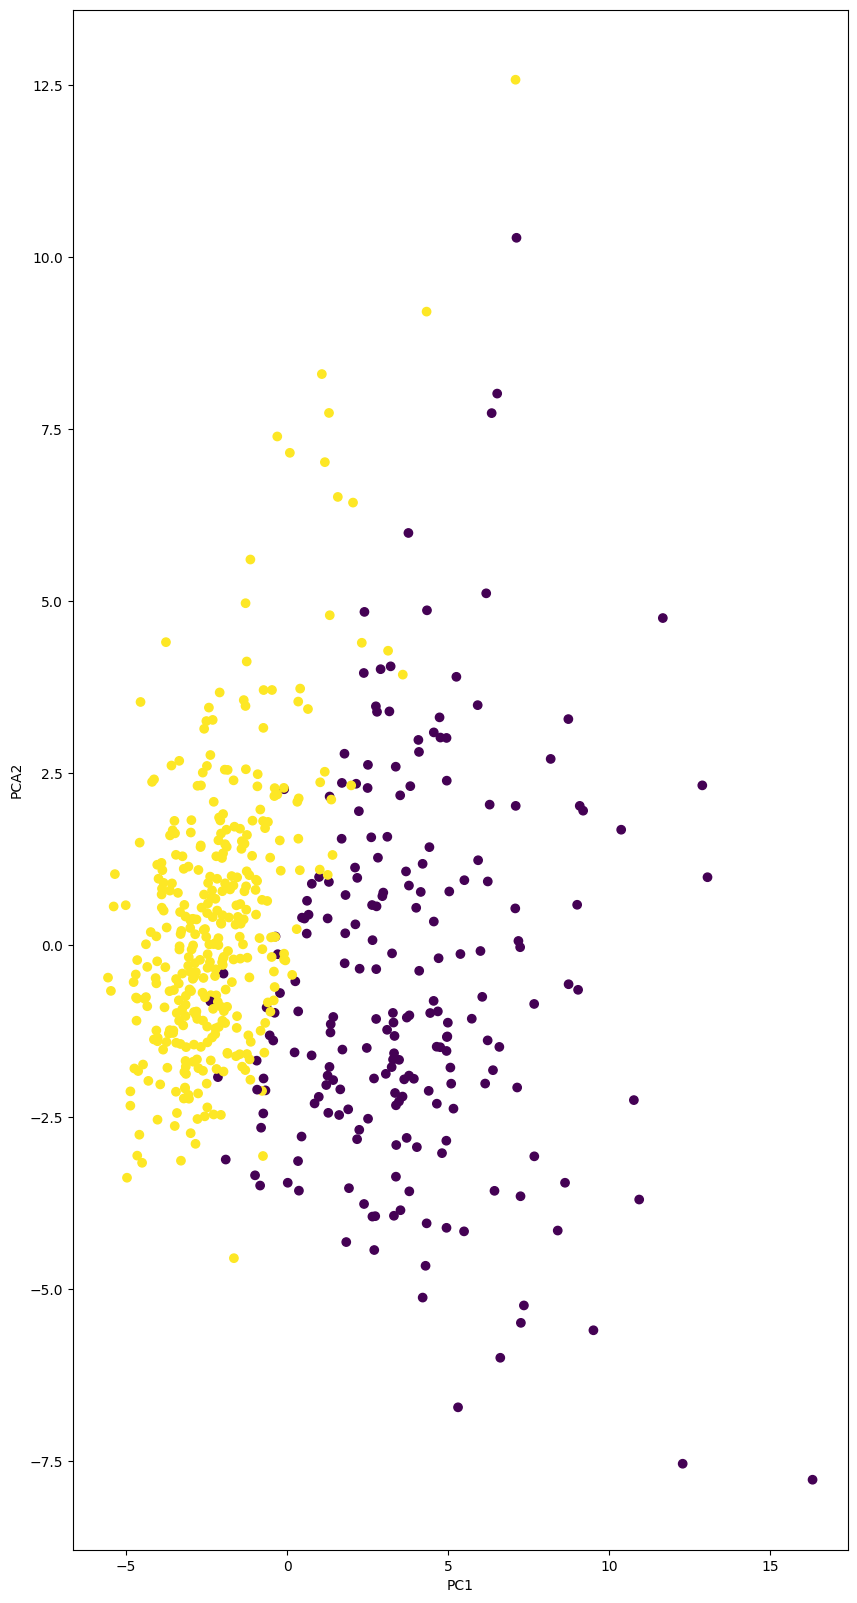

In [26]:
plt.figure(figsize=(10, 20))
plt.scatter(data_pca[:,0], data_pca[:,1], c = dataset["target"])
plt.xlabel("PC1")
plt.ylabel("PCA2")

In [24]:
# Pca withoit compenents 
pca2 = PCA()

dataset_pca2 = pca2.fit_transform(scaled_data)

In [25]:
pca2.explained_variance_

array([1.33049908e+01, 5.70137460e+00, 2.82291016e+00, 1.98412752e+00,
       1.65163324e+00, 1.20948224e+00, 6.76408882e-01, 4.77456255e-01,
       4.17628782e-01, 3.51310875e-01, 2.94433153e-01, 2.61621161e-01,
       2.41782421e-01, 1.57286149e-01, 9.43006956e-02, 8.00034045e-02,
       5.95036135e-02, 5.27114222e-02, 4.95647002e-02, 3.12142606e-02,
       3.00256631e-02, 2.74877113e-02, 2.43836914e-02, 1.80867940e-02,
       1.55085271e-02, 8.19203712e-03, 6.91261258e-03, 1.59213600e-03,
       7.50121413e-04, 1.33279057e-04])